[Link da apresentação](https://youtu.be/3OOKnJmpFN4)

In [228]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.utils import resample
from xgboost import XGBClassifier


## 1. Previsão de pagamento de empréstimos


In [229]:
comparativo = {}
# Plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

In [230]:
headers = ['ESCT', 'NDEP', 'RENDA', 'TIPOR', 'VBEM', 'NPARC', 'VPARC', 'TEL', 'IDADE', 'RESMS', 'ENTRADA', 'CLASSE']
data = pd.read_csv('data/credtrain.txt', sep='\t', names=headers)
test_data = pd.read_csv('data/credtest.txt', sep='\t', names=headers)

data[['ESCT', 'NDEP', 'TIPOR', 'TEL', 'CLASSE']] = data[['ESCT', 'NDEP', 'TIPOR', 'TEL', 'CLASSE']].astype('category')
test_data[['ESCT', 'NDEP', 'TIPOR', 'TEL', 'CLASSE']] = test_data[['ESCT', 'NDEP', 'TIPOR', 'TEL', 'CLASSE']].astype('category')

data.head(10)

,ESCT,NDEP,RENDA,TIPOR,VBEM,NPARC,VPARC,TEL,IDADE,RESMS,ENTRADA,CLASSE
0,1,0,360,0,313,9,52,0,25,48,0,1
1,0,0,350,1,468,10,65,0,33,6,0,1
2,0,0,1100,0,829,9,125,0,56,48,0,1
3,0,0,3000,0,552,12,76,1,31,60,0,1
4,1,0,1000,0,809,12,111,0,24,7,0,1
5,0,0,300,0,331,6,74,1,41,0,0,1
6,0,2,580,1,349,10,51,0,30,6,0,0
7,0,0,300,0,416,10,64,0,48,108,0,1
8,0,0,1500,0,688,6,148,0,59,48,0,0
9,0,1,500,1,828,18,89,0,29,6,0,1


In [231]:
categorical_ordinal = ['NDEP']
categorical_one_hot = ['ESCT', 'TIPOR', 'TEL']
continuous_features = ['RENDA', 'VBEM', 'NPARC', 'VPARC', 'IDADE', 'RESMS', 'ENTRADA']

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), continuous_features),
    ('one', OneHotEncoder(drop='first'), categorical_one_hot),
    ('ord', OrdinalEncoder(), categorical_ordinal)
])

X_processed = preprocessor.fit_transform(data)

# Get column names
num_feature_names = continuous_features
cat_feature_names = preprocessor.named_transformers_['one'].get_feature_names_out(categorical_one_hot).tolist()
ordinal_feature_names = categorical_ordinal

final_feature_names = num_feature_names + cat_feature_names + ordinal_feature_names

X_processed_df = pd.DataFrame(X_processed, columns=final_feature_names)

X_processed_df.head()

,RENDA,VBEM,NPARC,VPARC,IDADE,RESMS,ENTRADA,ESCT_1,ESCT_2,ESCT_3,TIPOR_1,TEL_1,NDEP
0,-0.689892,-0.937611,0.168333,-0.798003,-1.228280,0.312878,-0.342137,1.0,0.0,0.0,0.0,0.0,0.0
1,-0.700939,-0.354031,0.445500,-0.591544,-0.622121,-0.484925,-0.342137,0.0,0.0,0.0,1.0,0.0,0.0
2,0.127578,1.005145,0.168333,0.361347,1.120585,0.312878,-0.342137,0.0,0.0,0.0,0.0,0.0,0.0
3,2.226490,-0.037768,0.999835,-0.416847,-0.773661,0.540822,-0.342137,0.0,0.0,0.0,0.0,1.0,0.0
4,0.017109,0.929845,0.999835,0.139006,-1.304049,-0.465930,-0.342137,1.0,0.0,0.0,0.0,0.0,0.0


In [232]:
x = X_processed_df
y = data['CLASSE']

In [233]:
# Criar modelos
models_1 = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(),
}

for model_name, model in models_1.items():
    models_1[model_name].fit(x, y)


Logistic Regression:
[[290  16]
 [ 48 223]]


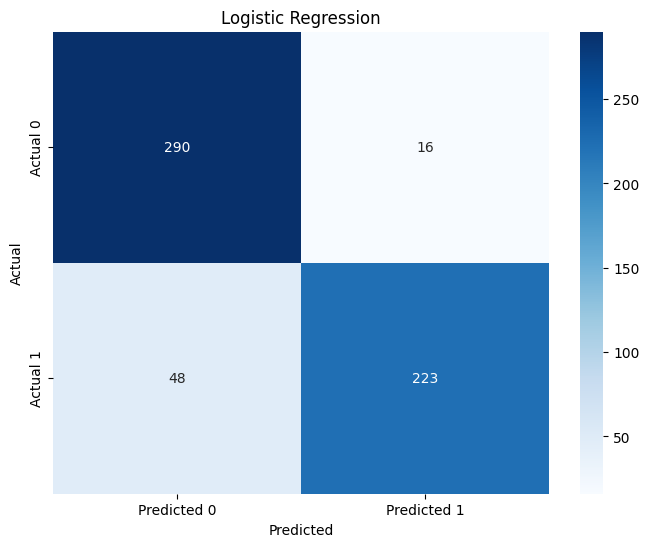

              precision    recall  f1-score   support

           0       0.86      0.95      0.90       306
           1       0.93      0.82      0.87       271

    accuracy                           0.89       577
   macro avg       0.90      0.89      0.89       577
weighted avg       0.89      0.89      0.89       577

KNN:
[[275  31]
 [ 55 216]]


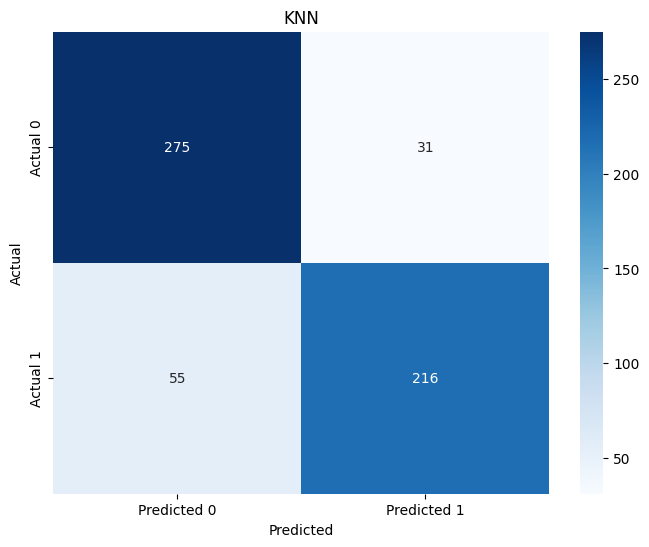

              precision    recall  f1-score   support

           0       0.83      0.90      0.86       306
           1       0.87      0.80      0.83       271

    accuracy                           0.85       577
   macro avg       0.85      0.85      0.85       577
weighted avg       0.85      0.85      0.85       577

XGBoost:
[[277  29]
 [ 40 231]]


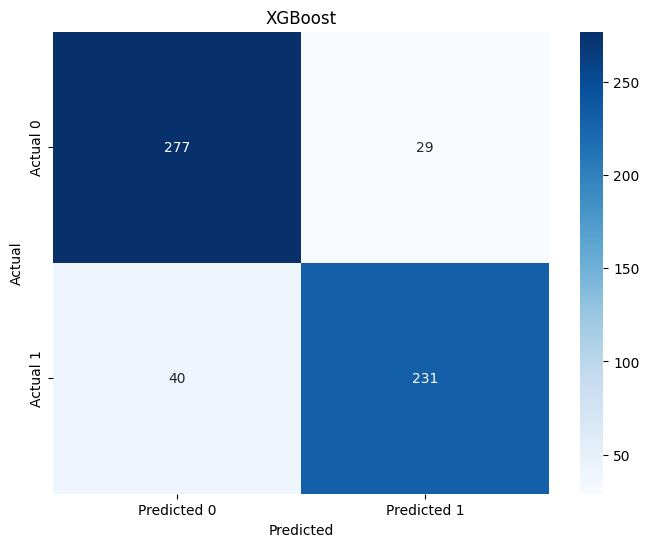

              precision    recall  f1-score   support

           0       0.87      0.91      0.89       306
           1       0.89      0.85      0.87       271

    accuracy                           0.88       577
   macro avg       0.88      0.88      0.88       577
weighted avg       0.88      0.88      0.88       577



In [234]:
X_test_processed = preprocessor.transform(test_data)

y_test = test_data['CLASSE']
X_test_processed_df = pd.DataFrame(X_test_processed, columns=final_feature_names)


# Criar modelos e fazer previsões
y_preds = {}
for model_name, model in models_1.items():
    y_preds[model_name] = model.predict(X_test_processed_df)

for model_name, y_pred in y_preds.items():
    print(f"{model_name}:")
    print(confusion_matrix(y_test, y_pred))
    plot_confusion_matrix(y_test, y_pred, model_name)
    report = classification_report(y_test, y_pred, output_dict=True)
    print(classification_report(y_test, y_pred))
    comparativo[f"{model_name}_1"] = report['accuracy']


In [235]:
pd.DataFrame.from_dict(comparativo, orient='index', columns=['Accuracy']).transpose()

,Logistic Regression_1,KNN_1,XGBoost_1
Accuracy,0.889081,0.850953,0.880416


## 2. Engenharia de Features

In [236]:
from category_encoders import GrayEncoder, CountEncoder

models_2 = {
    "Logistic Regression": LogisticRegression,
    "KNN": KNeighborsClassifier,
    "XGBoost": XGBClassifier,
}

In [237]:
# Carregar os dados de treino e teste
headers = ['ESCT', 'NDEP', 'RENDA', 'TIPOR', 'VBEM', 'NPARC', 'VPARC', 'TEL', 'IDADE', 'RESMS', 'ENTRADA', 'CLASSE']
data = pd.read_csv('data/credtrain.txt', sep='\t', names=headers)
test_data = pd.read_csv('data/credtest.txt', sep='\t', names=headers)

data[['ESCT', 'NDEP', 'TIPOR', 'TEL', 'CLASSE']] = data[['ESCT', 'NDEP', 'TIPOR', 'TEL', 'CLASSE']].astype('category')
test_data[['ESCT', 'NDEP', 'TIPOR', 'TEL', 'CLASSE']] = test_data[['ESCT', 'NDEP', 'TIPOR', 'TEL', 'CLASSE']].astype('category')

In [238]:
# Definir variáveis categóricas e contínuas
count_cat_col = ['ESCT']
ordinal_cat_col = ['NDEP']
one_hot_cat_col = ['TIPOR', 'TEL']
standard_num_col = ['RENDA', 'VBEM', 'NPARC', 'VPARC', 'IDADE', 'RESMS', 'ENTRADA']


preprocessor = ColumnTransformer([
        ('count', CountEncoder(normalize=True), count_cat_col),
        ('gray', GrayEncoder(), ordinal_cat_col),
        ('one_hot', OneHotEncoder(drop='first'), one_hot_cat_col),
        ('scaler', StandardScaler(), standard_num_col),
    ])

X_processed = preprocessor.fit_transform(data)

# Update final_feature_names to include the correct number of columns
cat_feature_names = preprocessor.named_transformers_['one_hot'].get_feature_names_out(one_hot_cat_col).tolist()
ordinal_feature_names = preprocessor.named_transformers_['gray'].get_feature_names_out(ordinal_cat_col).tolist()
count_feature_names = preprocessor.named_transformers_['count'].get_feature_names_out(count_cat_col).tolist()
num_feature_names = standard_num_col

final_feature_names = count_feature_names + ordinal_feature_names + cat_feature_names + num_feature_names

X_processed_df = pd.DataFrame(X_processed, columns=final_feature_names)

# Show the first few rows
X_processed_df.head()

,ESCT,NDEP_0,NDEP_1,NDEP_2,NDEP_3,TIPOR_1,TEL_1,RENDA,VBEM,NPARC,VPARC,IDADE,RESMS,ENTRADA
0,0.400667,0.0,0.0,0.0,1.0,0.0,0.0,-0.689892,-0.937611,0.168333,-0.798003,-1.228280,0.312878,-0.342137
1,0.556000,0.0,0.0,0.0,1.0,1.0,0.0,-0.700939,-0.354031,0.445500,-0.591544,-0.622121,-0.484925,-0.342137
2,0.556000,0.0,0.0,0.0,1.0,0.0,0.0,0.127578,1.005145,0.168333,0.361347,1.120585,0.312878,-0.342137
3,0.556000,0.0,0.0,0.0,1.0,0.0,1.0,2.226490,-0.037768,0.999835,-0.416847,-0.773661,0.540822,-0.342137
4,0.400667,0.0,0.0,0.0,1.0,0.0,0.0,0.017109,0.929845,0.999835,0.139006,-1.304049,-0.465930,-0.342137


In [239]:
X = X_processed_df
y = data["CLASSE"]

In [240]:
X_test_processed = preprocessor.transform(test_data)
y_test = test_data['CLASSE']

X_test_processed_df = pd.DataFrame(X_test_processed, columns=final_feature_names)

[[288  18]
 [ 46 225]]


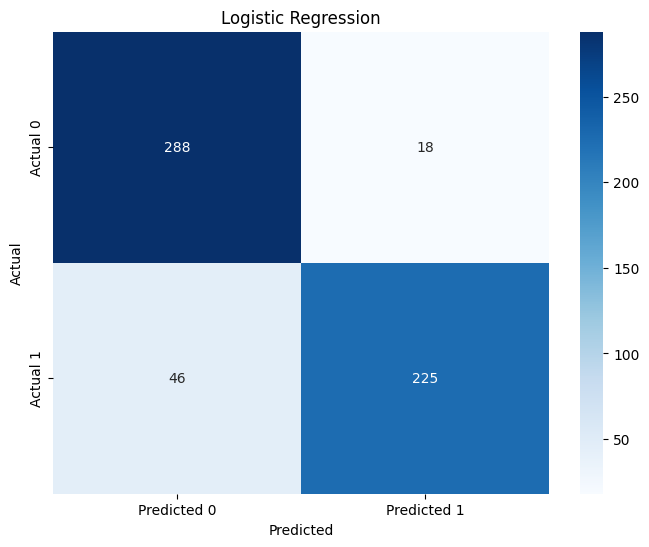

              precision    recall  f1-score   support

           0       0.86      0.94      0.90       306
           1       0.93      0.83      0.88       271

    accuracy                           0.89       577
   macro avg       0.89      0.89      0.89       577
weighted avg       0.89      0.89      0.89       577

[[275  31]
 [ 52 219]]


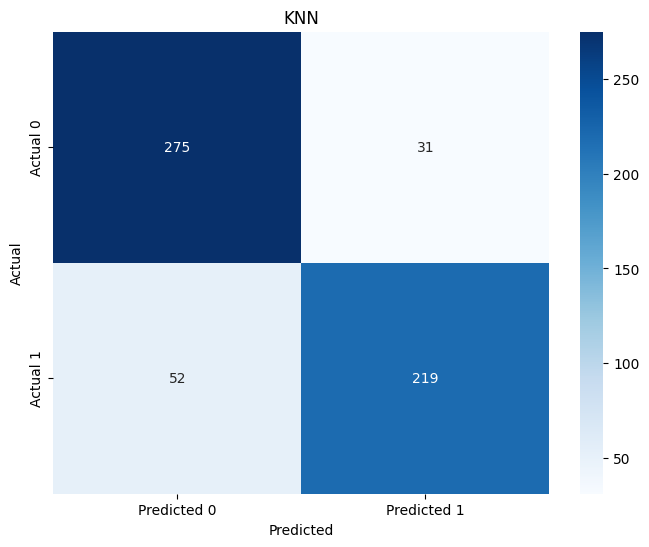

              precision    recall  f1-score   support

           0       0.84      0.90      0.87       306
           1       0.88      0.81      0.84       271

    accuracy                           0.86       577
   macro avg       0.86      0.85      0.85       577
weighted avg       0.86      0.86      0.86       577

[[280  26]
 [ 42 229]]


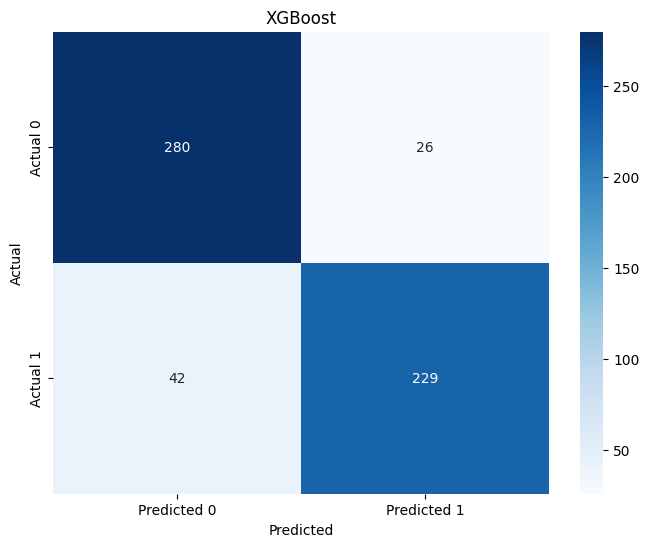

              precision    recall  f1-score   support

           0       0.87      0.92      0.89       306
           1       0.90      0.85      0.87       271

    accuracy                           0.88       577
   macro avg       0.88      0.88      0.88       577
weighted avg       0.88      0.88      0.88       577



In [241]:
# Testar cada modelo com os dados transformados
for model_name, model in models_1.items():
    model.fit(X, y)
    y_pred = model.predict(X_test_processed_df)
    print(confusion_matrix(y_test, y_pred))
    plot_confusion_matrix(y_test, y_pred, model_name)
    report = classification_report(y_test, y_pred, output_dict=True)
    print(classification_report(y_test, y_pred))
    comparativo[f"{model_name}_2"] = report['accuracy']

In [242]:
pd.DataFrame.from_dict(comparativo, orient='index', columns=['Accuracy']).transpose()


,Logistic Regression_1,KNN_1,XGBoost_1,Logistic Regression_2,KNN_2,XGBoost_2
Accuracy,0.889081,0.850953,0.880416,0.889081,0.856153,0.882149


## 3. Conjuntos desbalanceados - parte I

In [243]:
# Load the .npy files
X_train = pd.DataFrame(np.load('data/falldetection/X_train.npy'))
y_train = pd.DataFrame(np.load('data/falldetection/y_train.npy'))
X_val = pd.DataFrame(np.load('data/falldetection/X_val.npy'))
y_val = pd.DataFrame(np.load('data/falldetection/y_val.npy'))
X_test = pd.DataFrame(np.load('data/falldetection/X_test.npy'))
y_test = pd.DataFrame(np.load('data/falldetection/y_test.npy'))

results = {}

Train counts: [3194  428]
Validation counts: [1045  163]
Test counts: [1065  143]


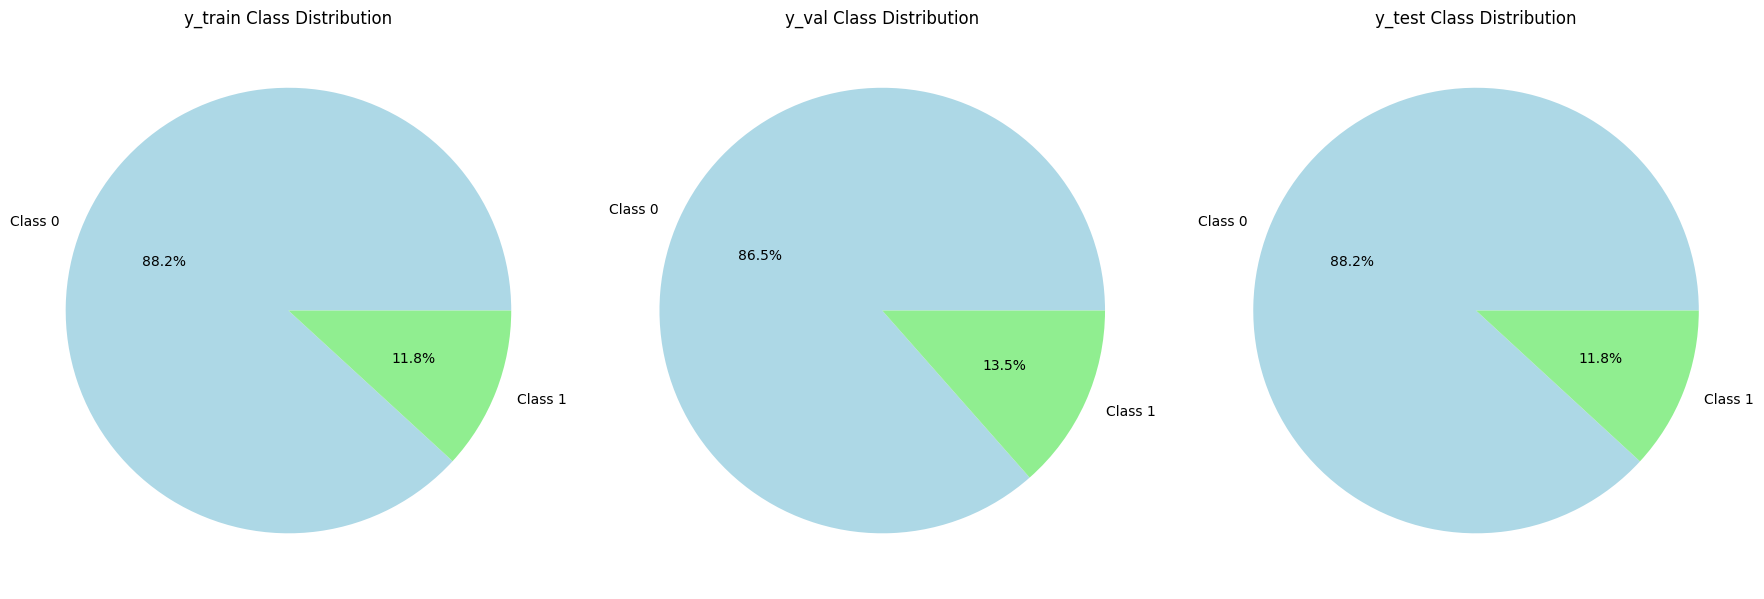

In [244]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# y_train distribution
train_counts = np.bincount(y_train[0])
axes[0].pie(train_counts, labels=['Class 0', 'Class 1'], autopct='%1.1f%%', colors=['lightblue', 'lightgreen'])
axes[0].set_title('y_train Class Distribution')

# y_val distribution
val_counts = np.bincount(y_val[0])
axes[1].pie(val_counts, labels=['Class 0', 'Class 1'], autopct='%1.1f%%', colors=['lightblue', 'lightgreen'])
axes[1].set_title('y_val Class Distribution')

# y_test distribution
test_counts = np.bincount(y_test[0])
axes[2].pie(test_counts, labels=['Class 0', 'Class 1'], autopct='%1.1f%%', colors=['lightblue', 'lightgreen'])
axes[2].set_title('y_test Class Distribution')

print(f"Train counts: {train_counts}")
print(f"Validation counts: {val_counts}")
print(f"Test counts: {test_counts}")
plt.tight_layout()
plt.show()

In [245]:
# Função para treinar e avaliar o modelo
def train_and_evaluate(X_train, y_train, X_val, y_val, title):
    model = XGBClassifier()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_val)
    
    report = classification_report(y_val, y_pred, output_dict=True)
    print(classification_report(y_val, y_pred))
    results[title] = report['accuracy']
    plot_confusion_matrix(y_val, y_pred, title)

              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1065
           1       0.93      0.72      0.81       143

    accuracy                           0.96      1208
   macro avg       0.95      0.86      0.89      1208
weighted avg       0.96      0.96      0.96      1208



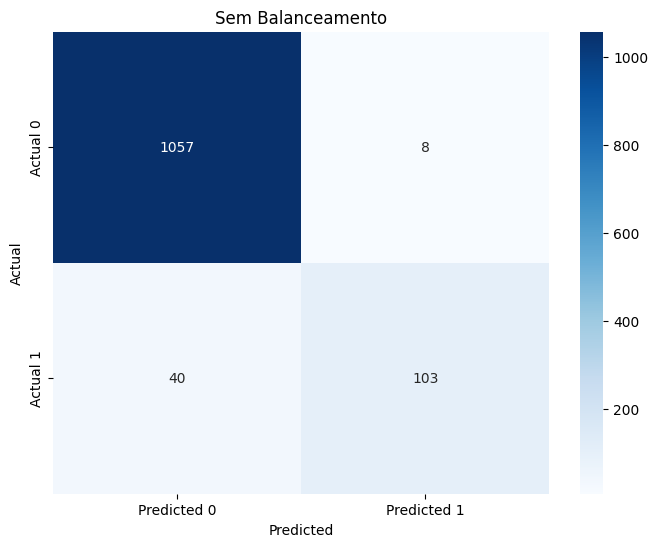

In [246]:
# Modelo sem balanceamento
train_and_evaluate(X_train, y_train, X_test, y_test, 'Sem Balanceamento')

In [ ]:
data = pd.concat([X_train, y_train.rename(columns={0: 'Response'})], axis=1)

Response_Zero = data[data['Response'] == 0]
Response_One = data[data['Response'] == 1]

len(Response_Zero) , len(Response_One)


(3194, 428)

Response
0    428
1    428
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       0.99      0.92      0.95      1045
           1       0.65      0.93      0.76       163

    accuracy                           0.92      1208
   macro avg       0.82      0.92      0.86      1208
weighted avg       0.94      0.92      0.93      1208



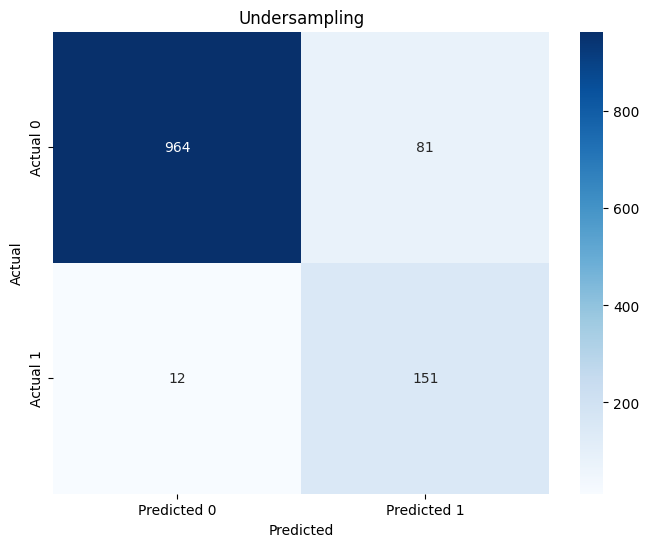

In [248]:
# Undersampling
downsampled_Zero = resample(Response_Zero, replace=False, n_samples=len(Response_One), random_state=42)
downsampled = pd.concat([downsampled_Zero, Response_One])

print(downsampled['Response'].value_counts())

X_train_undersampled = downsampled.drop(columns = ['Response'])
y_train_undersampled = downsampled['Response']

train_and_evaluate(X_train_undersampled, y_train_undersampled, X_val, y_val, 'Undersampling')

Response
0    3194
1    3194
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1045
           1       0.96      0.80      0.87       163

    accuracy                           0.97      1208
   macro avg       0.96      0.90      0.93      1208
weighted avg       0.97      0.97      0.97      1208



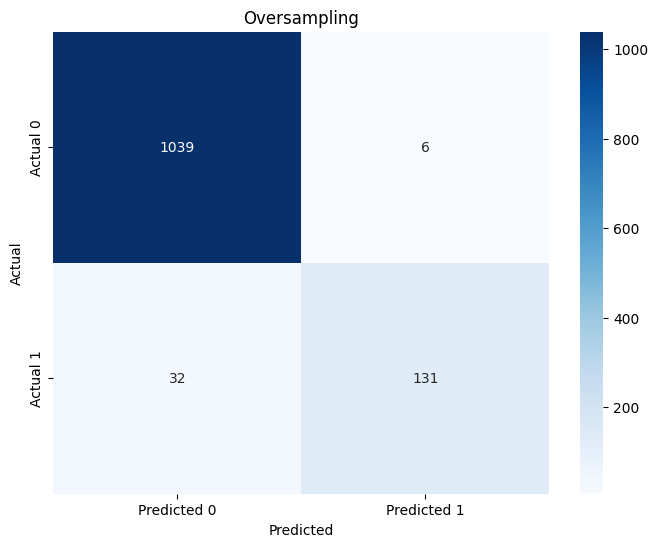

In [249]:
# Oversampling
upsampled_One = resample(Response_One, replace=True, n_samples=len(Response_Zero), random_state=42)
upsampled = pd.concat([Response_Zero, upsampled_One])

print(upsampled['Response'].value_counts())

X_train_oversampled = upsampled.drop(columns=['Response'])
y_train_oversampled = upsampled['Response']

train_and_evaluate(X_train_oversampled, y_train_oversampled, X_val, y_val, 'Oversampling')


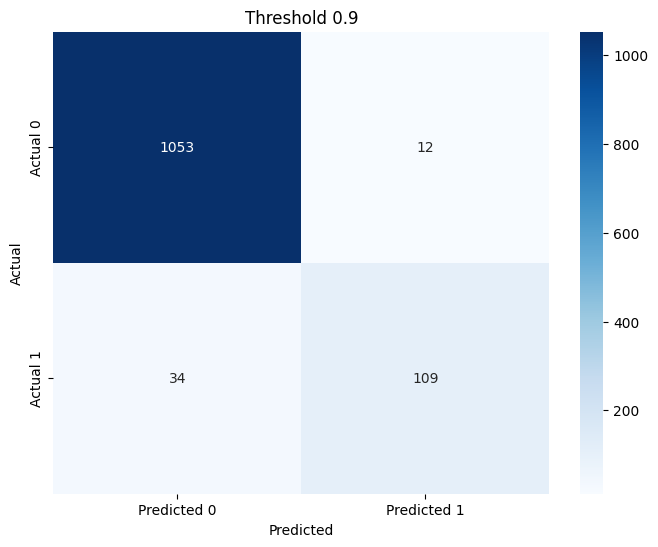

In [250]:
# Alteração de limiar
def predict_with_threshold(model, X, threshold=0.5):
    proba = model.predict_proba(X)[:, 1]
    return (proba >= threshold).astype(int)

model = XGBClassifier()
model.fit(X_train, y_train)

thresholds = np.linspace(0.1, 0.9, 5)
best_threshold = 0
best_accuracy = 0

for threshold in thresholds:
    y_pred_threshold = predict_with_threshold(model, X_test, threshold)
    report = classification_report(y_test, y_pred_threshold, output_dict=True)
    accuracy = report['accuracy']
    
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_threshold = threshold

y_pred_threshold = predict_with_threshold(model, X_test, best_threshold)
plot_confusion_matrix(y_test, y_pred_threshold, f"Threshold {threshold}")
report = classification_report(y_test, y_pred_threshold, output_dict=True)
accuracy = report['accuracy']
results[f"Threshold {threshold}"] = accuracy


In [252]:
pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy']).transpose()

,Sem Balanceamento,Undersampling,Oversampling,Threshold 0.9
Accuracy,0.960265,0.923013,0.968543,0.961921


## 5. Busca de hiperparâmetros

In [253]:
import optuna

X_train = np.load('data/falldetection/X_train.npy')
y_train = np.load('data/falldetection/y_train.npy')
X_val = np.load('data/falldetection/X_val.npy')
y_val = np.load('data/falldetection/y_val.npy')
X_test = np.load('data/falldetection/X_test.npy')
y_test = np.load('data/falldetection/y_test.npy')

def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'min_child_weight': trial.suggest_float('min_child_weight', 0.1, 10.0),
        'max_delta_step': trial.suggest_float('max_delta_step', 0, 10),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.5, 5.0),
    }

    model = XGBClassifier(**param)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    return accuracy

# Criar estudo e otimizar
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

best_params = study.best_params
print("Melhores hiperparâmetros:", best_params)

# Modelo com os melhores hiperparâmetros
best_model = XGBClassifier(**best_params)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)
best_accuracy = accuracy_score(y_test, y_pred_best)
print("Acurácia do modelo otimizado:", best_accuracy)

results['Modelo Otimizado'] = best_accuracy

# Mostrar resultados
pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy']).transpose()

d:\Estudos\BCC\Inteligencia Artifical\Trabalho 4\Codigo\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-02-14 17:12:22,382] A new study created in memory with name: no-name-cfde00e0-f1f9-4275-a0ae-b729fcf6e274
[I 2025-02-14 17:12:24,674] Trial 0 finished with value: 0.9685430463576159 and parameters: {'n_estimators': 114, 'max_depth': 4, 'learning_rate': 0.10090993343974111, 'subsample': 0.7409026456590448, 'colsample_bytree': 0.7849730017037655, 'gamma': 0.001308124501936988, 'reg_alpha': 7.707441495753728e-07, 'reg_lambda': 0.0003055266260116045, 'min_child_weight': 2.1882774308538413, 'max_delta_step': 4.188610090772271, 'scale_pos_weight': 4.244732715470425}. Best is trial 0 with value: 0.9685430463576159.
[I 2025-02-14 17:12:28,123] Trial 1 finished with value: 0.9652317880794702 and parameters: 

Melhores hiperparâmetros: {'n_estimators': 279, 'max_depth': 3, 'learning_rate': 0.10572488330559611, 'subsample': 0.7565819836240644, 'colsample_bytree': 0.6187780422073837, 'gamma': 8.281571966841758e-08, 'reg_alpha': 0.019539728725245547, 'reg_lambda': 0.002183985791564257, 'min_child_weight': 1.1744479424621246, 'max_delta_step': 1.6616448910531534, 'scale_pos_weight': 4.2022709718803135}
Acurácia do modelo otimizado: 0.9610927152317881


,Sem Balanceamento,Undersampling,Oversampling,Threshold 0.9,Modelo Otimizado
Accuracy,0.960265,0.923013,0.968543,0.961921,0.961093
